In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet(
    "../data/processed/uk_housing_analysis.parquet"
)

In [ ]:
How have UK house prices changed since 2019?

In [3]:
yearly_price = (
    df.groupby("Year")["Price"]
      .mean()
      .reset_index()
)

yearly_price

,Year,Price
0,2019,304093.679392
1,2020,325146.789768
2,2021,346464.646257
3,2022,364460.151106
4,2023,359077.039914
5,2024,361786.891199
6,2025,360286.657656


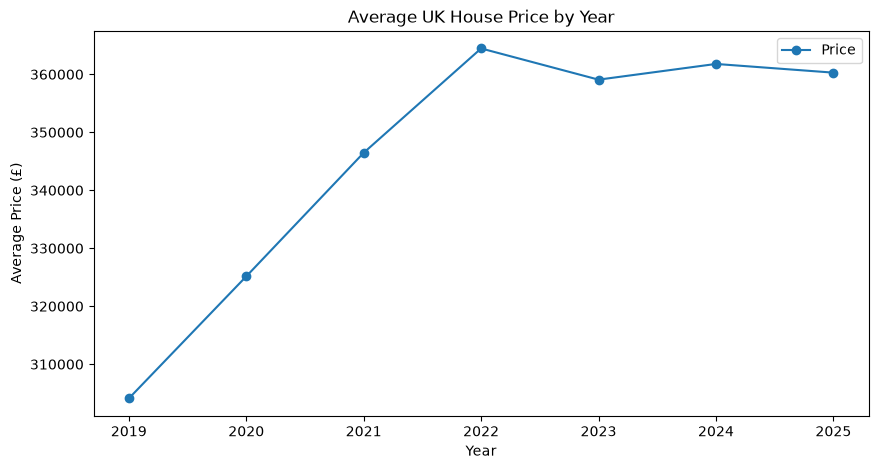

In [5]:
yearly_price.plot(
    x="Year",
    y="Price",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average UK House Price by Year")
plt.ylabel("Average Price (£)")
plt.show()

In [ ]:
How many transactions happen each year?

In [6]:
transactions = (
    df.groupby("Year")
      .size()
      .reset_index(name="Transactions")
)

transactions

,Year,Transactions
0,2019,1003820
1,2020,890614
2,2021,1273087
3,2022,1069507
4,2023,854917
5,2024,921966
6,2025,875636


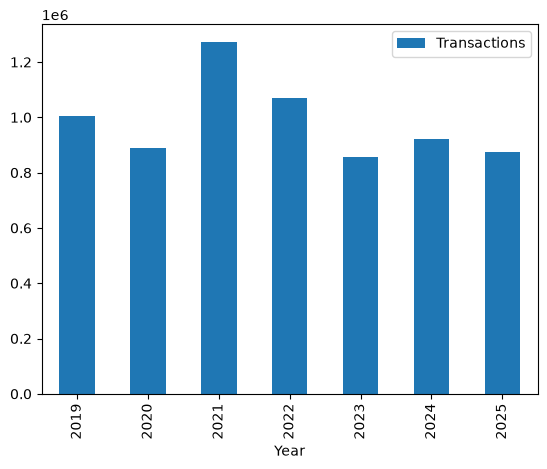

In [7]:
transactions.plot(
    x="Year",
    y="Transactions",
    kind="bar"
)

plt.show()

In [ ]:
Which property type is most expensive?

In [8]:
property_price = (
    df.groupby(
        "Property_Type_Name"
    )["Price"]
    .mean()
    .sort_values(
        ascending=False
    )
)

property_price

Property_Type_Name
Other            539681.703278
Detached         475731.483581
Flat             308279.955839
Semi-Detached    295875.415384
Terraced         269821.173967
Name: Price, dtype: float64

<Axes: xlabel='Property_Type_Name'>

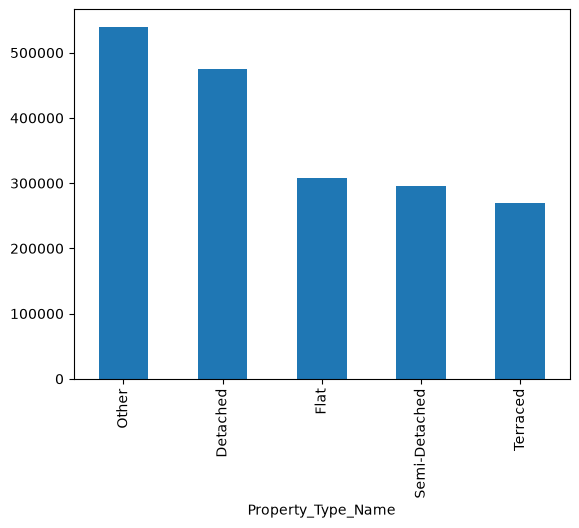

In [9]:
property_price.plot(
    kind="bar"
)

In [ ]:
Top 10 most expensive counties

In [10]:
county_price = (
    df.groupby("County")
      ["Price"]
      .mean()
      .sort_values(
          ascending=False
      )
      .head(10)
)

county_price

County
WINDSOR AND MAIDENHEAD          647136.901005
GREATER LONDON                  637414.002870
SURREY                          597546.367031
BUCKINGHAMSHIRE                 547187.236934
HERTFORDSHIRE                   523468.409810
WOKINGHAM                       509235.490877
BATH AND NORTH EAST SOMERSET    477999.535058
OXFORDSHIRE                     475250.191774
BRIGHTON AND HOVE               470504.863237
WEST BERKSHIRE                  462327.791491
Name: Price, dtype: float64

<Axes: ylabel='County'>

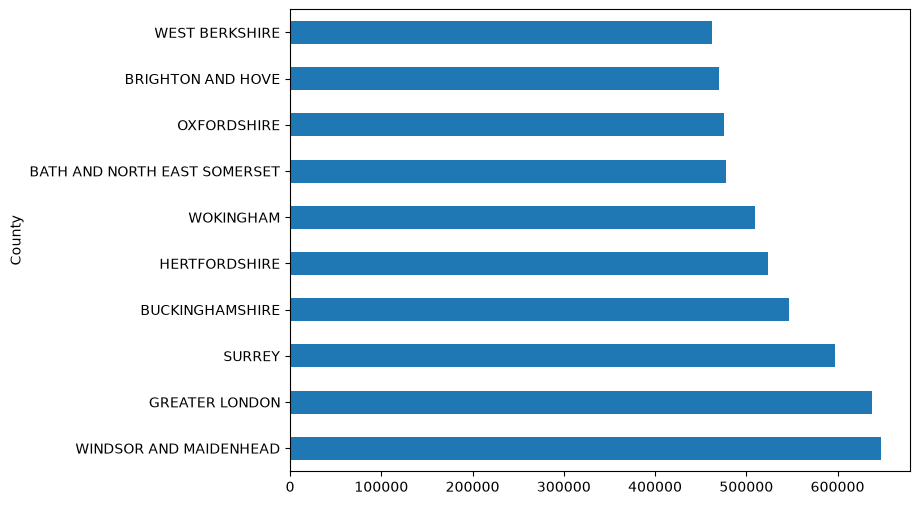

In [11]:
county_price.plot(
    kind="barh",
    figsize=(8, 6)
)

In [ ]:
New Build vs Existing Properties

In [12]:
df.groupby(
    "New_Build"
)["Price"].mean()

New_Build
No     343619.839425
Yes    363121.805763
Name: Price, dtype: float64

In [ ]:
Freehold vs Leasehold

In [13]:
df.groupby(
    "Tenure"
)["Price"].mean()

Tenure
Freehold     361640.622511
Leasehold    292423.046525
Name: Price, dtype: float64

In [ ]:
Seasonality

<Axes: xlabel='Month'>

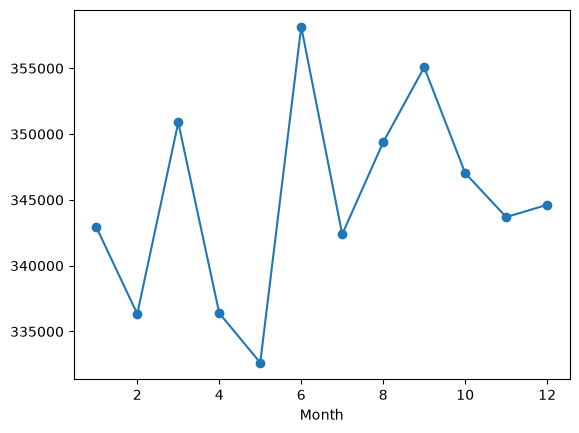

In [14]:
monthly_price = (
    df.groupby("Month")
      ["Price"]
      .mean()
)

monthly_price.plot(
    marker="o"
)